In [5]:
import numpy as np
import pyDOE as doe
from mpl_toolkits import mplot3d
from sklearn.preprocessing import MinMaxScaler
import pandas as pds
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

In [6]:
#file =('/Users/shubhamjamdade/Desktop/Paper O2_He/New - Data Processing/Delta_H_top_10/Finding Topt.xlsx')
file =('/Users/shubhamjamdade/Desktop/Paper O2_He/Final Data Processing/GCMC_Data/All Data.xlsx')
Data = pds.read_excel(file, 'Regression_finding_Topt_10' )

Delta_H_100 = np.array(Data['T_100']).reshape(-1,1)
Delta_H_120 = np.array(Data['T_120']).reshape(-1,1)
Delta_H_140 = np.array(Data['T_140']).reshape(-1,1)
Delta_H_160 = np.array(Data['T_160']).reshape(-1,1)
Delta_H_180 = np.array(Data['T_180']).reshape(-1,1)
Delta_H_200 = np.array(Data['T_200']).reshape(-1,1)
Delta_H_220 = np.array(Data['T_220']).reshape(-1,1)
Delta_H_240 = np.array(Data['T_240']).reshape(-1,1)
Delta_H_260 = np.array(Data['T_260']).reshape(-1,1)
Delta_H_280 = np.array(Data['T_280']).reshape(-1,1)
Delta_H_300 = np.array(Data['T_300']).reshape(-1,1)


y = np.hstack((Delta_H_100, Delta_H_120, Delta_H_140, Delta_H_160, Delta_H_180, Delta_H_200, Delta_H_220, Delta_H_240, Delta_H_260, Delta_H_280, Delta_H_300))
print(y.shape)

(220, 11)


In [7]:
# x = np.array([100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]).reshape(-1,1)

# plt.plot(x, Delta_H_100, c='green')
# plt.plot(x, Delta_H_120, c='green')
# plt.plot(x, Delta_H_140, c='green')
# plt.plot(x, Delta_H_160, c='green')
# plt.plot(x, Delta_H_180, c='green')
# plt.plot(x, Delta_H_200, c='green')
# plt.plot(x, Delta_H_220, c='green')
# plt.plot(x, Delta_H_240, c='green')
# plt.plot(x, Delta_H_260, c='green')
# plt.plot(x, Delta_H_280, c='green')
# plt.plot(x, Delta_H_300, c='green')

# plt.plot([80.40102941,320.9177792], [-6.1716905,-28.36473195], c= "red", marker='.', linestyle=':')
# #plt.gca().invert_yaxis()
# plt.show()

In [8]:
from pyomo.environ import *
import pyomo.environ as pe

##An example will be provided that is not going to be equal to the features you should use, but will be there to modify for use.
def mat_1(x):
#   Return matrix of 1, x1, x1^2, x1^3, x1^4.  Dimension: (n_samples, 8)
    m, n = np.shape(x)
    #mat = np.array([np.ones(m), x[:,0], x[:,0]**2, x[:,0]**3, x[:,0]**4]).T
    mat = np.array([np.ones(m), x[:,0], x[:,0]**2]).T
    return mat


# create index list for training points

points_list = np.linspace(1, 11, num=11)

feature_list = np.linspace(1, 3, num=3)

No_of_MOFs = 10

In [9]:
x = np.array([100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300]).reshape(-1,1)

X = mat_1(x) 

xdic={}

for j in range(len(feature_list)):
    for i in range(len(points_list)):
        xdic[(i+1,j+1)]=X[i,j]    
        
Y = y.T

ydic={}

for j in range(No_of_MOFs):
    for i in range(len(points_list)):
        ydic[(i+1,j+1)]=float(Y[i,j])
        
print(X.shape)
print(Y.shape)

(11, 3)
(11, 220)



parameter values:

b1:[-16.1854294]

b2:[0.03747287]

b3:[-3.5514918e-05]

For lamda=1e-06, R2: 0.99934678898392
objective function = 0.015688383007260578
[3281.45110727  138.88248284]

parameter values:

b1:[-19.49225832]

b2:[0.07079661]

b3:[-9.61151973e-05]

For lamda=1e-06, R2: 0.9982063214920646
objective function = 0.08489052817662295
[1472.83805697  137.69402618]

parameter values:

b1:[-14.3615376]

b2:[0.04166703]

b3:[-5.37240477e-05]

For lamda=1e-06, R2: 0.9999298946224547
objective function = 0.0012980220325949038
[2218.63168606  120.48888968]

parameter values:

b1:[-15.81990732]

b2:[0.03388503]

b3:[-3.65773855e-05]

For lamda=1e-06, R2: 0.9998887985406195
objective function = 0.0018501571601367928
[3082.58788021  140.30585975]

parameter values:

b1:[-14.41265396]

b2:[0.04307431]

b3:[-5.71294405e-05]

For lamda=1e-06, R2: 0.9999076056194384
objective function = 0.0017183831465447778
[2104.44268092  119.88004236]

parameter values:

b1:[-17.92655171]

b2:[0.06407202

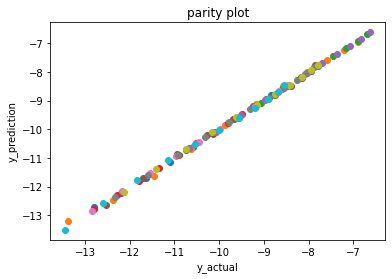

In [10]:
for k in range(1, No_of_MOFs +1):
    model = ConcreteModel()   
    #Define Data:
    model.m = points_list
    model.n = feature_list
    model.yact = ydic
    model.xs = xdic

    model.ypred = Var(model.m)

    model.b = Var(model.n)

    lamda =  0.000001

    def obj_rule(model):
        return sum((sum((model.b[j]*model.xs[i,j]) for j in model.n)-model.yact[i,k])**2 for i in model.m) + lamda*sum(abs(model.b[j]) for j in model.n)
    model.obj = Objective(rule=obj_rule) 

    #same as above:
    solver = SolverFactory('baron')
    solver.solve(model)

    s = (len(points_list),1)
    y_predict = np.zeros(s)

    for i in range(1, len(points_list)+1 ):

        for j in range(1, len(feature_list)+1):

            y_predict [i-1] = y_predict [i-1] + value(model.b[j])*value(model.xs[i,j])

    c = np.empty((len(feature_list),1))

    print('\nparameter values:')
    for i in range(len(feature_list)):
        c[i,0] = value(model.b[i+1])
        print('\nb'+str(i+1)+':'+str(c[i]))


    print('\nFor lamda='+str(lamda)+', R2: '+str(r2_score(y_predict, Y[:,k-1])))
    print('objective function =', value(model.obj))

    plt.scatter(y_predict,  Y[:,k-1])
    plt.xlabel('y_actual')
    plt.ylabel('y_prediction')
    plt.title('parity plot')
    
    p = [value(model.b[3]), value(model.b[2]) + 0.084, value(model.b[1])]
    #p = [value(model.b[5]), value(model.b[4]), value(model.b[3]), value(model.b[2]) + 0.0923, value(model.b[1])]
    roots = np.roots(p)
    print(roots)


In [11]:
R2= []
T = []
for k in range(1, No_of_MOFs +1):
    model = ConcreteModel()   
    #Define Data:
    model.m = points_list
    model.n = feature_list
    model.yact = ydic
    model.xs = xdic

    model.ypred = Var(model.m)

    model.b = Var(model.n)

    lamda =  0.000001

    def obj_rule(model):
        return sum((sum((model.b[j]*model.xs[i,j]) for j in model.n)-model.yact[i,k])**2 for i in model.m) + lamda*sum(abs(model.b[j]) for j in model.n)
    model.obj = Objective(rule=obj_rule) 

    #same as above:
    solver = SolverFactory('baron')
    solver.solve(model)

    s = (len(points_list),1)
    y_predict = np.zeros(s)

    for i in range(1, len(points_list)+1 ):

        for j in range(1, len(feature_list)+1):

            y_predict [i-1] = y_predict [i-1] + value(model.b[j])*value(model.xs[i,j])

    c = np.empty((len(feature_list),1))

#     print('\nparameter values:')
#     for i in range(len(feature_list)):
#         c[i,0] = value(model.b[i+1])
#         print('\nb'+str(i+1)+':'+str(c[i]))


#     print('\nFor lamda='+str(lamda)+', R2: '+str(r2_score(y_predict, Y[:,k-1])))
#     print('objective function =', value(model.obj))

#     plt.scatter(y_predict,  Y[:,k-1])
#     plt.xlabel('y_actual')
#     plt.ylabel('y_prediction')
#     plt.title('parity plot')

    R2.append(r2_score(y_predict, Y[:,k-1]))
    
    #p = [value(model.b[5]), value(model.b[4]), value(model.b[3]), value(model.b[2]) + 0.0923, value(model.b[1])]
    p = [value(model.b[3]), value(model.b[2]) + 0.084, value(model.b[1])]
    roots = np.roots(p)
    for i in range(len(roots)):
        
        if roots[i].imag == 0 and 100 < roots[i].real < 300:
            T.append(roots[i])
            
print(R2)
print(T)

[0.99934678898392, 0.9982063214920646, 0.9999298946224547, 0.9998887985406195, 0.9999076056194384, 0.9982051987114087, 0.9998112486597153, 0.9995174719269418, 0.9992957846752816, 0.9989674123142726]
[138.88248283993346, 137.69402618274444, 120.48888968021157, 140.30585974525783, 119.88004236101266, 133.25071333912484, 138.06617196268704, 132.85680566715254, 131.24739343635807, 140.58925177149774]
